# **TALLER DE REGRESIÓN LINEAL Y MODELOS DE PREDICCIÓN**

### **Base de datos de monóxido de carbono (CO) — Monterey County, 2022**

En este taller se replica el procedimiento desarrollado en el taller original, manteniendo el mismo orden general de análisis, pero adaptándolo a la base de datos de **CO del año 2022 para Monterey County, California**.

**1. IMPORTAMOS PAQUETES**

In [18]:
import numpy as np                # Cálculos numéricos y manejo de arreglos/matrices
import pandas as pd               # Organizar, limpiar y analizar datos en forma de tabla
import matplotlib.pyplot as plt   # Crear gráficos
import seaborn as sns             # Crear gráficos estadísticos

%matplotlib inline
# Hace que los gráficos de Matplotlib aparezcan dentro de la celda de Colab/Jupyter.

**2. CARGA DEL CONJUNTO DE DATOS**

In [19]:
df = pd.read_csv("/content/ad_viz_plotval_data.csv")
df.head() # vemos los 5 primeros datos del dataframe

,Date,Source,Site ID,POC,Daily Max 8-hour CO Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,...,AQS Parameter Description,Method Code,CBSA Code,CBSA Name,State FIPS Code,State,County FIPS Code,County,Site Latitude,Site Longitude
0,01/01/2022,AQS,60531003,1,0.7,ppm,8,Salinas 3,19,79.0,...,Carbon monoxide,54,41500,"Salinas, CA",6,California,53,Monterey,36.694261,-121.623271
1,01/02/2022,AQS,60531003,1,0.4,ppm,5,Salinas 3,24,100.0,...,Carbon monoxide,54,41500,"Salinas, CA",6,California,53,Monterey,36.694261,-121.623271
2,01/03/2022,AQS,60531003,1,0.4,ppm,5,Salinas 3,24,100.0,...,Carbon monoxide,54,41500,"Salinas, CA",6,California,53,Monterey,36.694261,-121.623271
3,01/04/2022,AQS,60531003,1,0.3,ppm,3,Salinas 3,24,100.0,...,Carbon monoxide,54,41500,"Salinas, CA",6,California,53,Monterey,36.694261,-121.623271
4,01/05/2022,AQS,60531003,1,0.2,ppm,2,Salinas 3,24,100.0,...,Carbon monoxide,54,41500,"Salinas, CA",6,California,53,Monterey,36.694261,-121.623271


**3. CONSULTAR INFORMACIÓN BÁSICA SOBRE EL CONJUNTO DE DATOS**

* **info()** >> Permite revisar la estructura del DataFrame, el número de registros, las columnas, los valores no nulos y el tipo de dato de cada variable.

* **describe()** >> Resume las principales estadísticas descriptivas de las variables numéricas, como media, desviación estándar, mínimo, máximo y cuartiles.

In [20]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Date                               365 non-null    object 
 1   Source                             365 non-null    object 
 2   Site ID                            365 non-null    int64  
 3   POC                                365 non-null    int64  
 4   Daily Max 8-hour CO Concentration  365 non-null    float64
 5   Units                              365 non-null    object 
 6   Daily AQI Value                    365 non-null    int64  
 7   Local Site Name                    365 non-null    object 
 8   Daily Obs Count                    365 non-null    int64  
 9   Percent Complete                   365 non-null    float64
 10  AQS Parameter Code                 365 non-null    int64  
 11  AQS Parameter Description          365 non-null    object 

In [21]:
df.describe().round(2)

,Site ID,POC,Daily Max 8-hour CO Concentration,Daily AQI Value,Daily Obs Count,Percent Complete,AQS Parameter Code,Method Code,CBSA Code,State FIPS Code,County FIPS Code,Site Latitude,Site Longitude
count,365.0,365.0,365.00,365.00,365.00,365.00,365.0,365.0,365.0,365.0,365.0,365.00,365.00
mean,60531003.0,1.0,0.30,3.21,23.93,99.69,42101.0,54.0,41500.0,6.0,53.0,36.69,-121.62
std,0.0,0.0,0.15,1.82,0.73,3.07,0.0,0.0,0.0,0.0,0.0,0.00,0.00
min,60531003.0,1.0,0.10,1.00,14.00,58.00,42101.0,54.0,41500.0,6.0,53.0,36.69,-121.62
25%,60531003.0,1.0,0.20,2.00,24.00,100.00,42101.0,54.0,41500.0,6.0,53.0,36.69,-121.62
50%,60531003.0,1.0,0.30,3.00,24.00,100.00,42101.0,54.0,41500.0,6.0,53.0,36.69,-121.62
75%,60531003.0,1.0,0.30,3.00,24.00,100.00,42101.0,54.0,41500.0,6.0,53.0,36.69,-121.62
max,60531003.0,1.0,1.30,15.00,24.00,100.00,42101.0,54.0,41500.0,6.0,53.0,36.69,-121.62


In [22]:
df.columns

Index(['Date', 'Source', 'Site ID', 'POC', 'Daily Max 8-hour CO Concentration',
       'Units', 'Daily AQI Value', 'Local Site Name', 'Daily Obs Count',
       'Percent Complete', 'AQS Parameter Code', 'AQS Parameter Description',
       'Method Code', 'CBSA Code', 'CBSA Name', 'State FIPS Code', 'State',
       'County FIPS Code', 'County', 'Site Latitude', 'Site Longitude'],
      dtype='object')

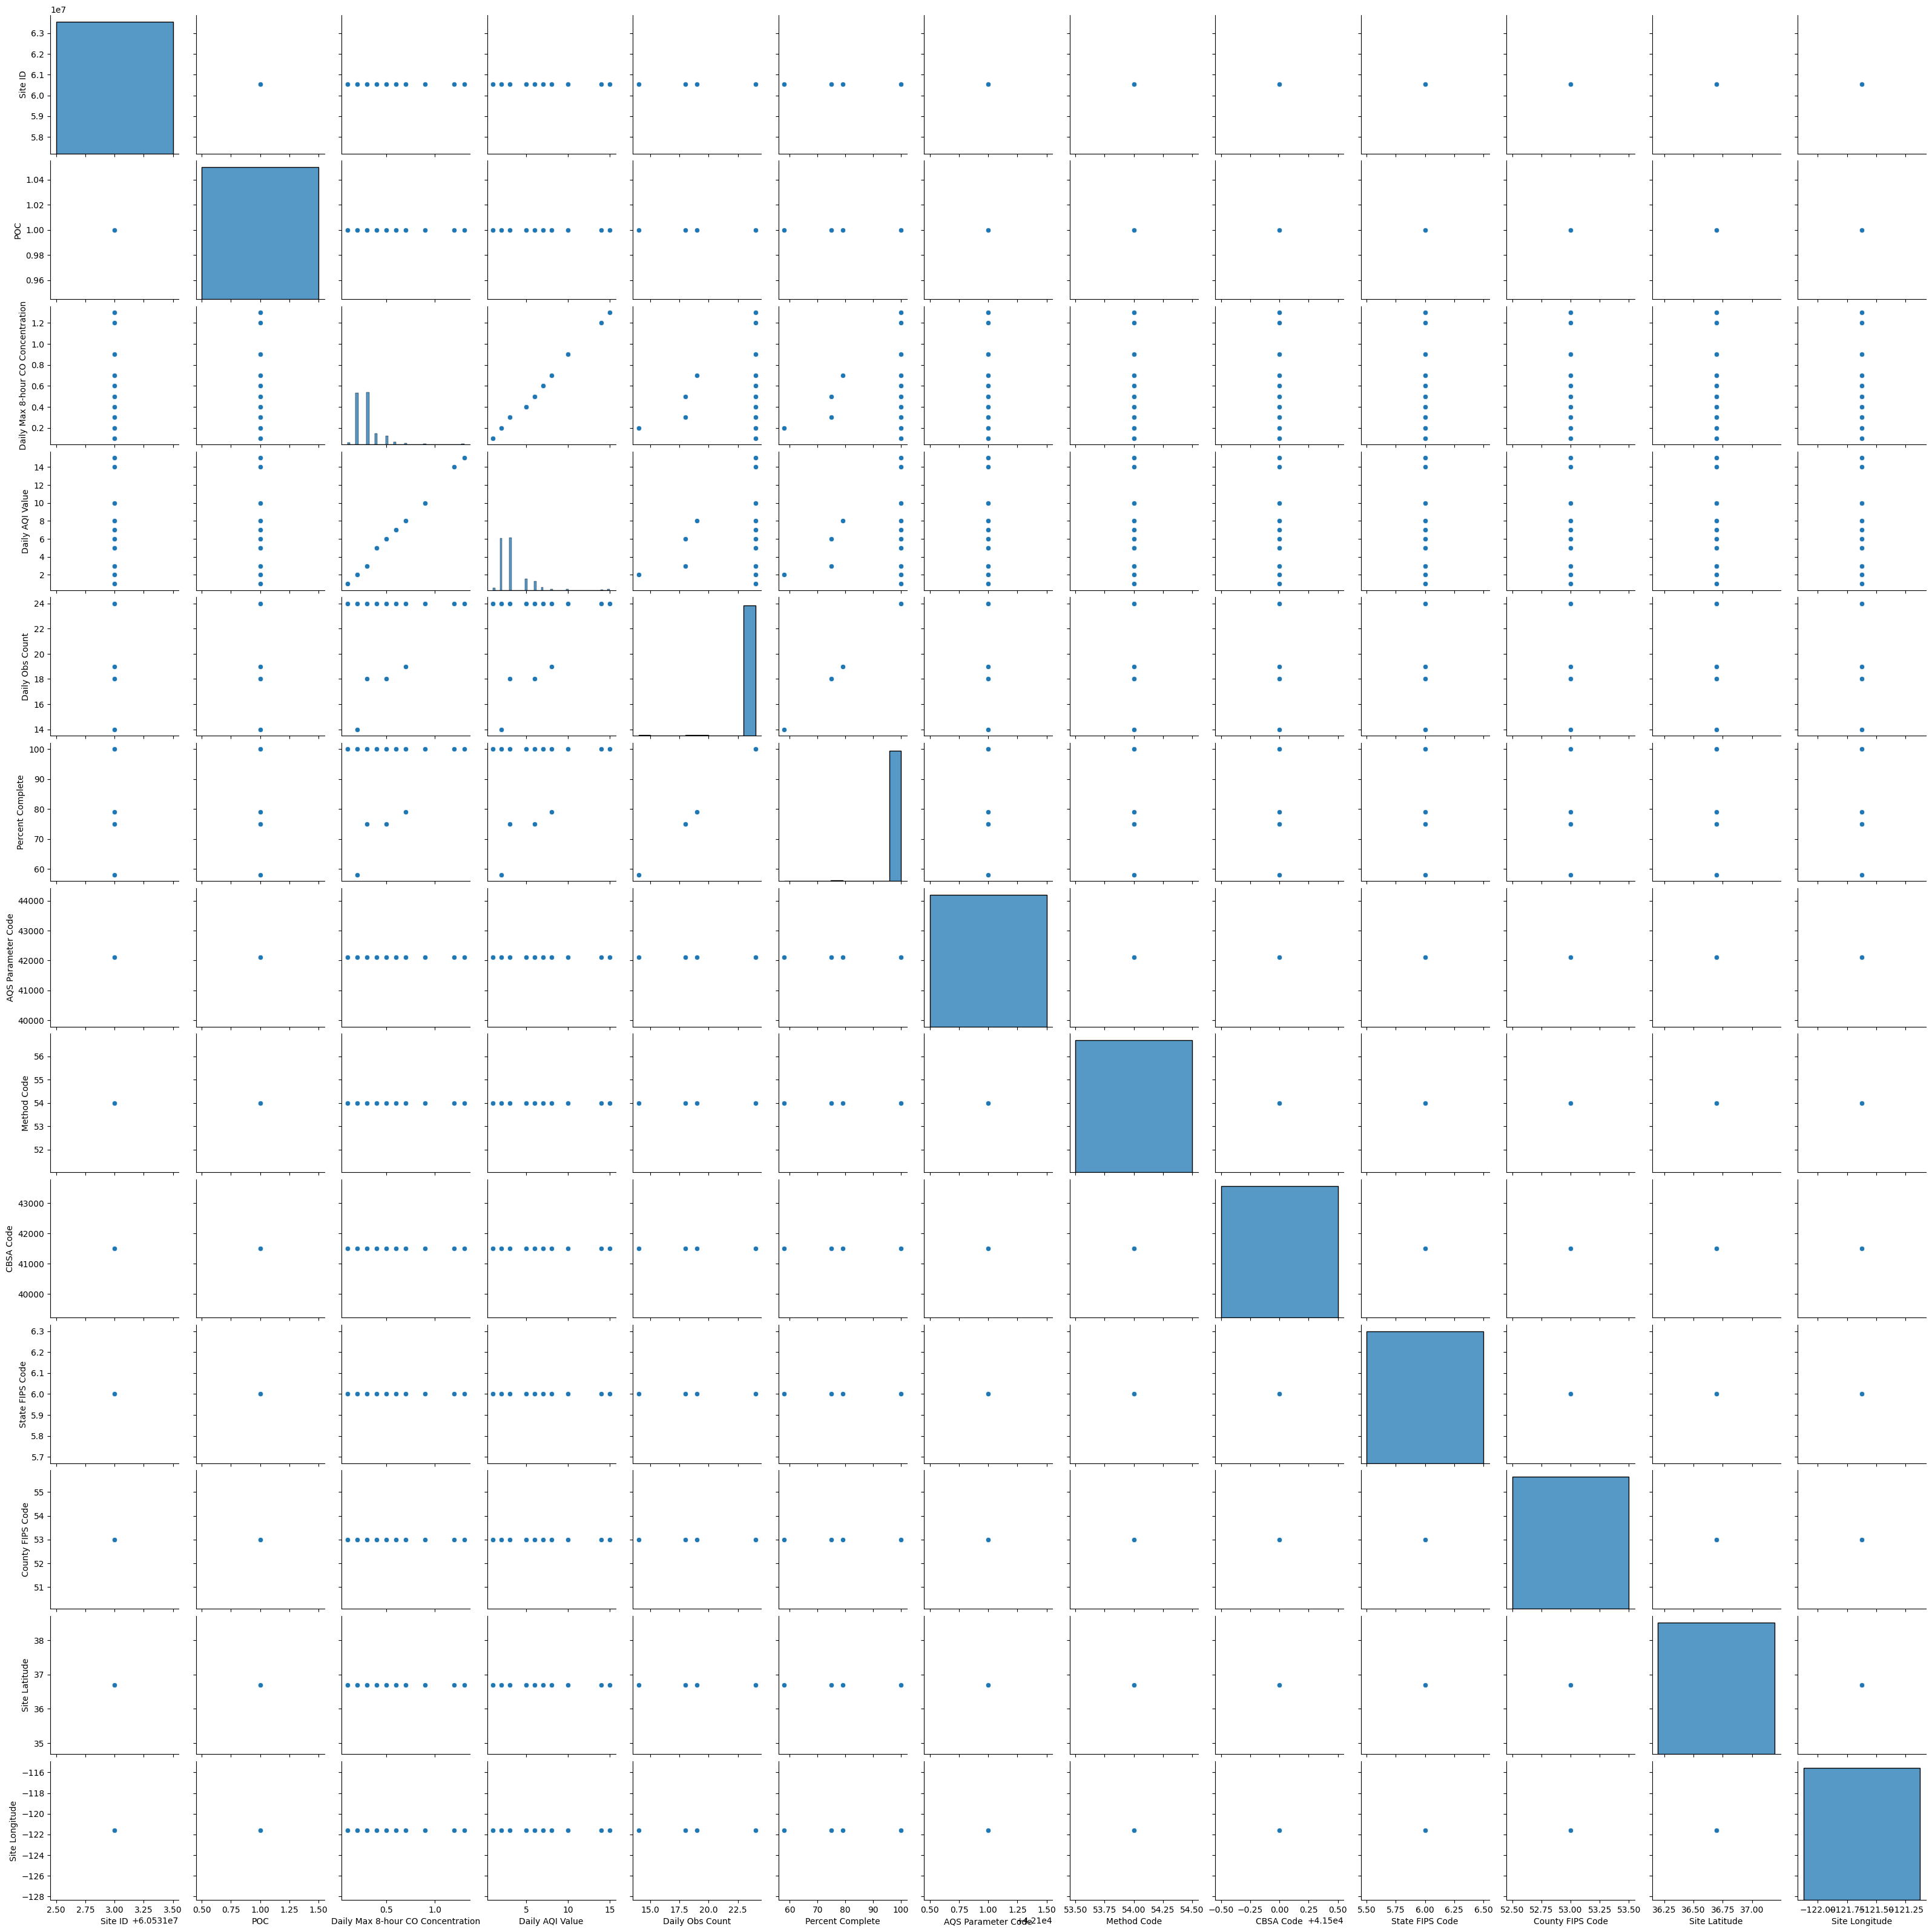

In [23]:
# Visualización conjunta de las variables numéricas.
# Se seleccionan únicamente las variables numéricas para evitar problemas
# con columnas de texto como State, County, Units, etc.
numeric_df = df.select_dtypes(include=[np.number])
sns.pairplot(numeric_df)

**4. DISTRIBUCIÓN DE LA CONCENTRACIÓN DE CO**

<Axes: ylabel='Frequency'>

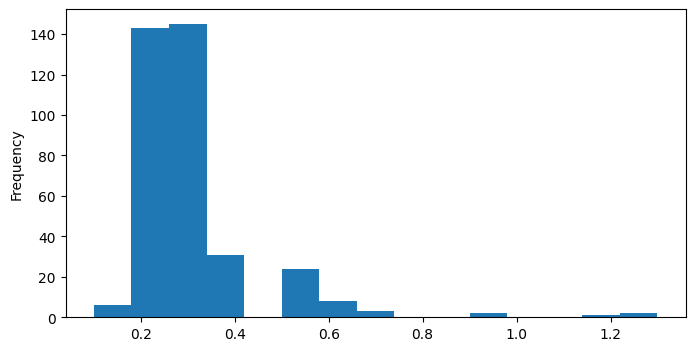

In [24]:
df["Daily Max 8-hour CO Concentration"].plot.hist(bins=15, figsize=(8,4))

# Histograma con 15 intervalos.
# Permite observar cómo se distribuyen los valores de concentración máxima
# diaria de CO en un periodo de 8 horas.

<Axes: ylabel='Density'>

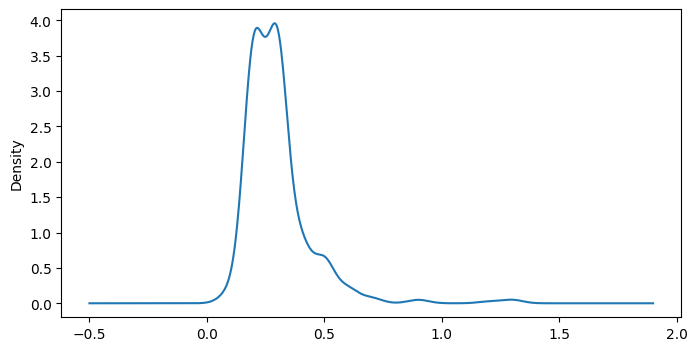

In [25]:
df["Daily Max 8-hour CO Concentration"].plot.density(figsize=(8,4))

# Densidad: permite observar dónde se concentran los valores de CO.

**5. MATRIZ DE CORRELACIÓN Y HEATMAP**

In [26]:
numeric_df = df.select_dtypes(include=[np.number])

numeric_df.corr().round(4)
# Cálculo de la correlación entre las variables numéricas.

,Site ID,POC,Daily Max 8-hour CO Concentration,Daily AQI Value,Daily Obs Count,Percent Complete,AQS Parameter Code,Method Code,CBSA Code,State FIPS Code,County FIPS Code,Site Latitude,Site Longitude
Site ID,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
POC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Daily Max 8-hour CO Concentration,NaN,NaN,1.0000,0.9914,-0.0567,-0.0566,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Daily AQI Value,NaN,NaN,0.9914,1.0000,-0.0567,-0.0566,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Daily Obs Count,NaN,NaN,-0.0567,-0.0567,1.0000,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Percent Complete,NaN,NaN,-0.0566,-0.0566,1.0000,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AQS Parameter Code,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Method Code,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CBSA Code,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State FIPS Code,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
numeric_df = df.select_dtypes(include=[np.number])

# Quitamos las columnas constantes (desviación estándar = 0), ya que no aportan información y generan NaN en la correlación (una columna sin variación no puede correlacionarse con nada).
numeric_df = numeric_df.loc[:, numeric_df.std() > 0]

numeric_df.corr().round(4)
# Cálculo de la correlación entre las variables numéricas realmente variables.

,Daily Max 8-hour CO Concentration,Daily AQI Value,Daily Obs Count,Percent Complete,Site Latitude,Site Longitude
Daily Max 8-hour CO Concentration,1.0000,0.9914,-0.0567,-0.0566,NaN,NaN
Daily AQI Value,0.9914,1.0000,-0.0567,-0.0566,NaN,NaN
Daily Obs Count,-0.0567,-0.0567,1.0000,1.0000,NaN,NaN
Percent Complete,-0.0566,-0.0566,1.0000,1.0000,NaN,NaN
Site Latitude,NaN,NaN,NaN,NaN,NaN,NaN
Site Longitude,NaN,NaN,NaN,NaN,NaN,NaN


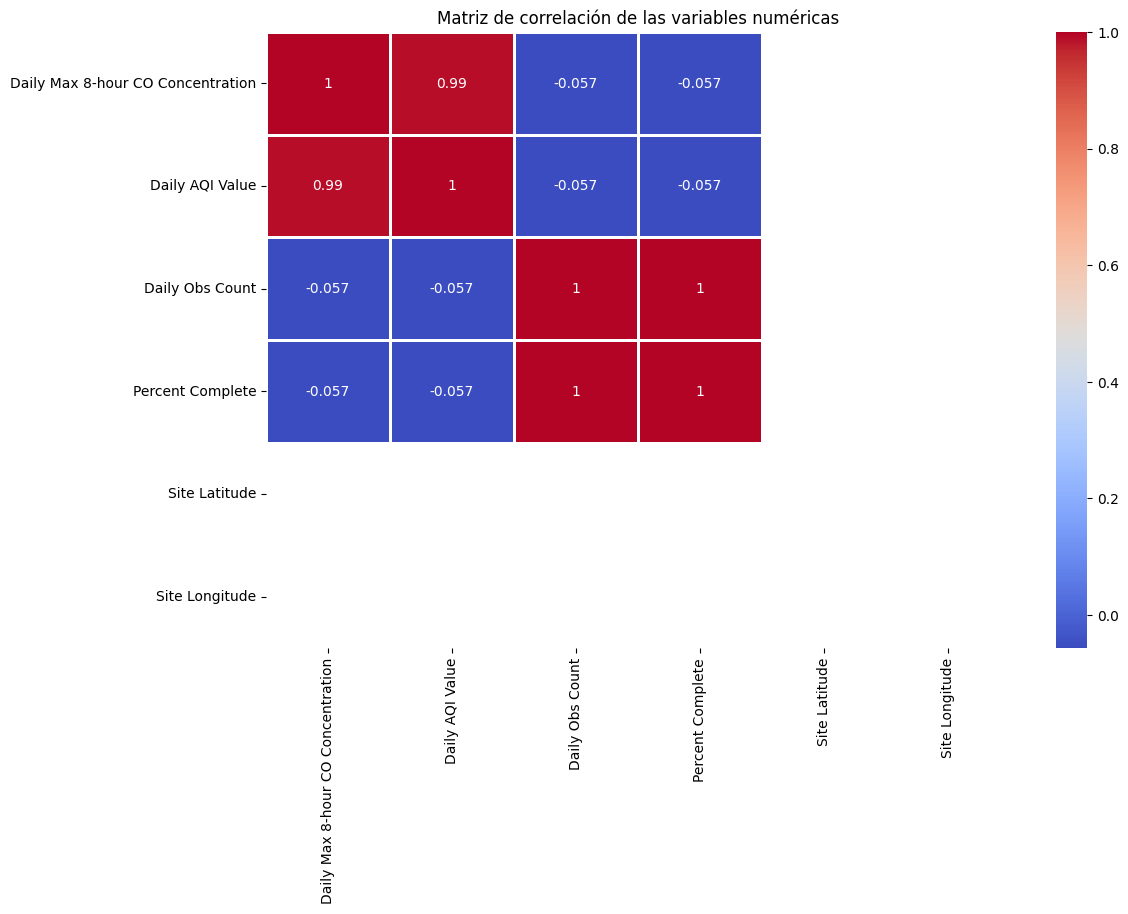

In [28]:
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, linewidths=1, cmap="coolwarm")
plt.title("Matriz de correlación de las variables numéricas")
plt.show()

# El mapa de calor permite identificar relaciones lineales entre variables.
# IMPORTANTE: Daily AQI Value no se utilizará como predictor del CO,
# porque el AQI está calculado a partir de la calidad del aire y puede
# introducir fuga de información (data leakage) al intentar predecir CO.

**6. CONJUNTO DE CARACTERÍSTICAS Y VARIABLE OBJETIVO**

En esta base de datos, la variable objetivo será **Daily Max 8-hour CO Concentration**, que representa la concentración máxima diaria de CO en un periodo de 8 horas.

Para la regresión se construyen variables temporales a partir de **Date** y se incorpora la información disponible sobre la cantidad y completitud de las observaciones. Se excluyen identificadores, códigos administrativos y variables constantes, ya que no aportan capacidad explicativa útil al modelo.

In [29]:
# Convertimos la fecha al formato datetime
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")

# Variables temporales
df["Month"] = df["Date"].dt.month
df["Day_of_Year"] = df["Date"].dt.dayofyear
df["Day_of_Week"] = df["Date"].dt.dayofweek

# Variable objetivo
target = "Daily Max 8-hour CO Concentration"

# Características seleccionadas
features = [
    "Month",
    "Day_of_Year",
    "Day_of_Week",
    "Percent Complete"
]

X = df[features]
y = df[target]

print("Características utilizadas:")
print(X.columns.tolist())
print("\nVariable objetivo:")
print(y.name)

X.head()

Características utilizadas:
['Month', 'Day_of_Year', 'Day_of_Week', 'Percent Complete']

Variable objetivo:
Daily Max 8-hour CO Concentration


,Month,Day_of_Year,Day_of_Week,Percent Complete
0,1,1,5,79.0
1,1,2,6,100.0
2,1,3,0,100.0
3,1,4,1,100.0
4,1,5,2,100.0


In [30]:
y.head()

,Daily Max 8-hour CO Concentration
0,0.7
1,0.4
2,0.4
3,0.3
4,0.2


* **MATRIZ DE CORRELACIÓN REDUCIDA (VARIABLES RELEVANTES)**

  El heatmap de la sección 5 incluye todas las columnas numéricas del dataset (Site ID, POC, CBSA Code, coordenadas, etc.), muchas de las cuales son constantes para esta estación y por eso aparecen vacías en el gráfico, además de que se construyó antes de crear las variables temporales (`Month`, `Day_of_Year`, `Day_of_Week`).

  Aquí se genera una versión **reducida y más legible**, con solo las variables realmente relevantes para el modelo (la variable objetivo, el AQI, las variables de completitud y las variables temporales ya construidas), usando nombres cortos y un tamaño de figura más compacto. Los valores de correlación son exactamente los mismos que en la matriz completa; solo cambia qué se muestra y cómo se presenta.

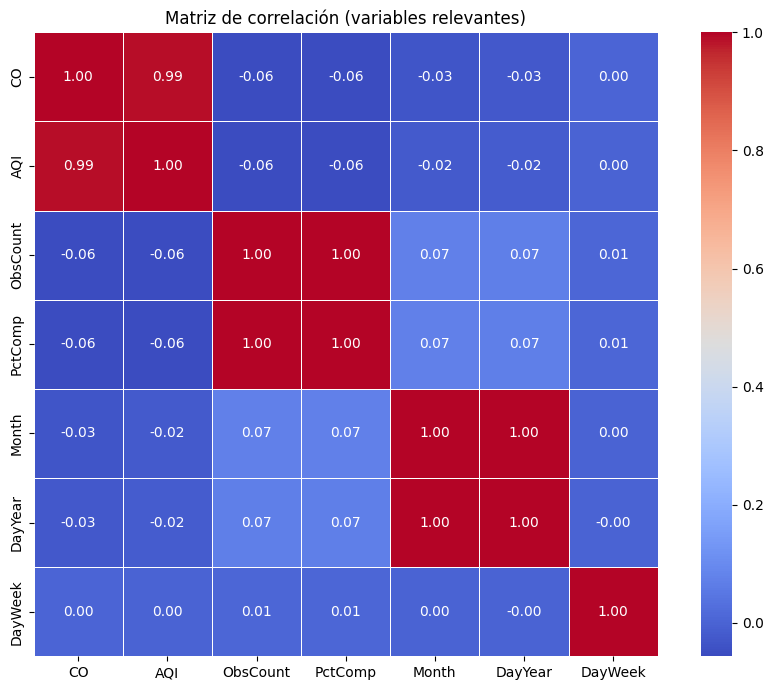

In [31]:
cols = ["Daily Max 8-hour CO Concentration", "Daily AQI Value",
        "Daily Obs Count", "Percent Complete",
        "Month", "Day_of_Year", "Day_of_Week"]

corr_reducida = df[cols].corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr_reducida, annot=True, fmt=".2f", linewidths=0.5,
            cmap="coolwarm", square=True,
            xticklabels=["CO","AQI","ObsCount","PctComp","Month","DayYear","DayWeek"],
            yticklabels=["CO","AQI","ObsCount","PctComp","Month","DayYear","DayWeek"])
plt.title("Matriz de correlación (variables relevantes)")
plt.tight_layout()
plt.show()

# A diferencia del heatmap de la sección 5, aquí solo se muestran las variables
# que realmente aportan al análisis, lo que facilita la lectura de las relaciones
# clave: CO-AQI (fuga de información) y ObsCount-PercentComplete (multicolinealidad).

**7. REGRESIÓN LINEAL**

In [32]:
from sklearn.model_selection import train_test_split
# Divide los datos en entrenamiento y prueba

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=123
)

# 70%: entrenamiento
# 30%: prueba
# random_state=123 >>> Hace la división aleatoria reproducible

**8. AJUSTE Y ENTRENAMIENTO DEL MODELO**

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# machine learning
# modelo: regresión lineal
# métricas: permiten evaluar qué tan buenas son las predicciones.

In [35]:
lm = LinearRegression() # Creando un objeto de regresión lineal "lm"

In [36]:
lm.fit(X_train, y_train) # Ajustar y entrenar

LinearRegression()

In [37]:
# Verificamos la intercepción
print("El término de intersección del modelo lineal:", lm.intercept_)

El término de intersección del modelo lineal: 0.637283008430167


In [38]:
# Verificamos el modelo lineal
print("Los coeficientes del modelo lineal:", lm.coef_)

Los coeficientes del modelo lineal: [-1.86751848e-02  6.51259710e-04 -3.76082499e-05 -3.38947847e-03]


In [39]:
cdf = pd.DataFrame(
    data=lm.coef_,
    index=X_train.columns,
    columns=["Coefficients"]
)
cdf

,Coefficients
Month,-0.018675
Day_of_Year,0.000651
Day_of_Week,-0.000038
Percent Complete,-0.003389


* **INTERPRETACIÓN:**

   La regresión lineal obtenida tendrá la forma:

   **CO = Intercepto + β₁(Month) + β₂(Day_of_Year) + β₃(Day_of_Week) + β4(Percent Complete)**

   Cada coeficiente representa el cambio esperado en la concentración de CO cuando aumenta una unidad la variable correspondiente, manteniendo constantes las demás variables.

**9. CÁLCULO DE ERRORES ESTÁNDAR Y ESTADÍSTICA T PARA LOS COEFICIENTES**

In [40]:
n = X_train.shape[0]                 # cantidad de datos de entrenamiento
k = X_train.shape[1]                 # cantidad de variables
dfN = n - k                           # grados de libertad

train_pred = lm.predict(X_train)     # obtener predicciones

# Calculamos el error cuadrático
train_error = np.square(train_pred - y_train)
sum_error = np.sum(train_error)

print("Número de observaciones de entrenamiento:", n)
print("Número de variables:", k)
print("Grados de libertad:", dfN)
print("Suma de errores cuadrados:", sum_error)

Número de observaciones de entrenamiento: 255
Número de variables: 4
Grados de libertad: 251
Suma de errores cuadrados: 5.452825382805256


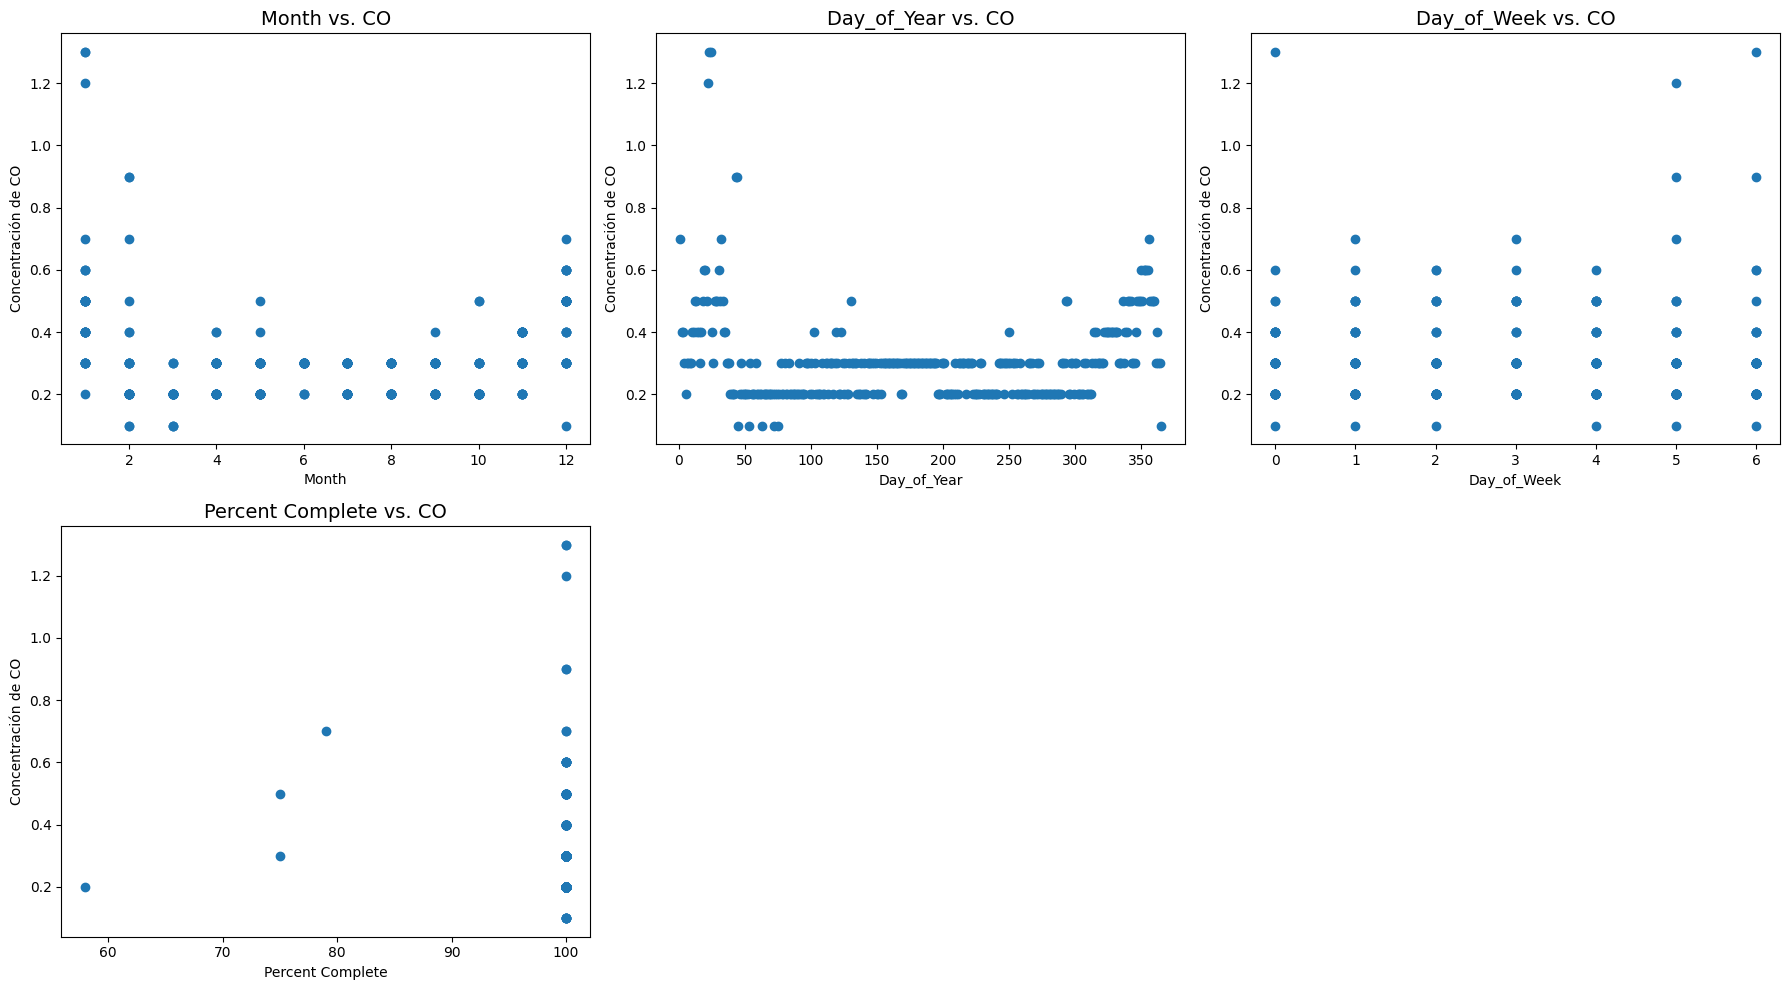

In [41]:
# Gráficos de dispersión de cada característica frente a la concentración de CO
l = list(cdf.index)

fig = plt.figure(figsize=(18, 10))

for i, col in enumerate(l):
    ax = plt.subplot(2, 3, i + 1)
    ax.scatter(df[col], df["Daily Max 8-hour CO Concentration"])
    ax.set_title(col + " vs. CO", fontsize=14)
    ax.set_xlabel(col)
    ax.set_ylabel("Concentración de CO")

plt.tight_layout()
plt.show()

**10. MATRIZ DE EVALUACIÓN DE PREDICCIÓN Y DIAGRAMA DE DISPERSIÓN**

In [42]:
predictions = lm.predict(X_test)

print("Tipo del objeto predicho :", type(predictions))
print("Tamaño del objeto predicho:", predictions.shape)

Tipo del objeto predicho : <class 'numpy.ndarray'>
Tamaño del objeto predicho: (110,)


**Diagrama de dispersión**

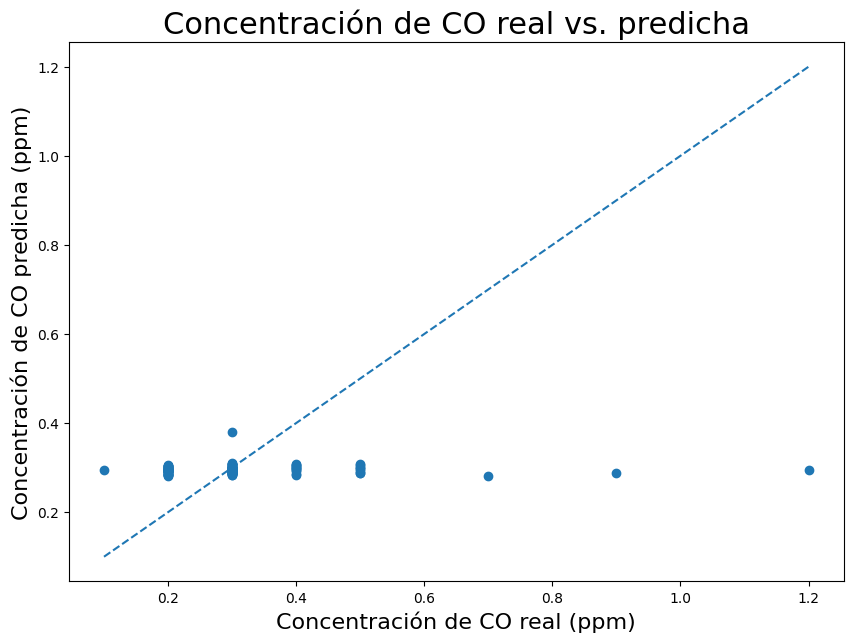

In [43]:
plt.figure(figsize=(10,7))
plt.title("Concentración de CO real vs. predicha", fontsize=22)
plt.xlabel("Concentración de CO real (ppm)", fontsize=16)
plt.ylabel("Concentración de CO predicha (ppm)", fontsize=16)
plt.scatter(x=y_test, y=predictions)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--")
plt.show()

# Si los puntos se acercan a la línea de 45°, las predicciones se aproximan
# a los valores reales.

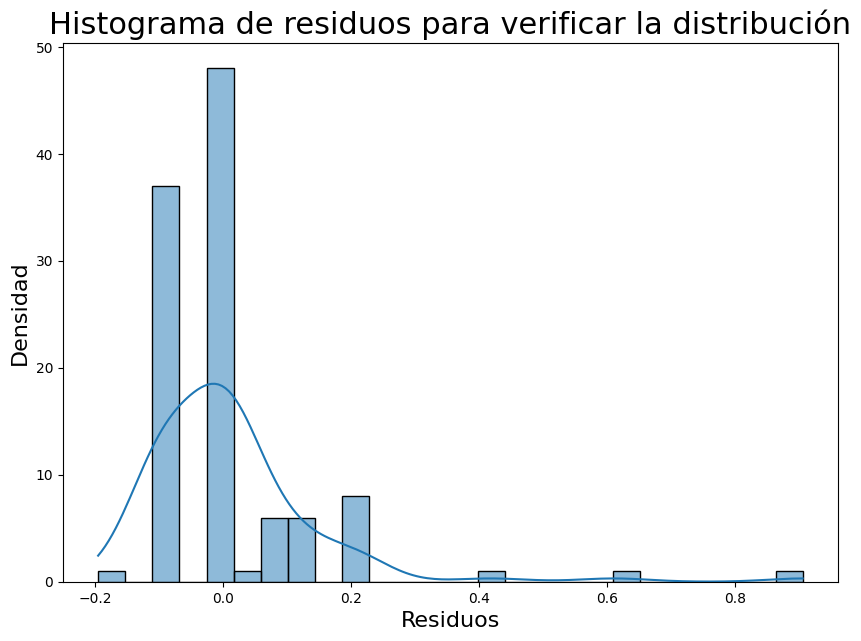

In [44]:
residuos = y_test - predictions

plt.figure(figsize=(10,7))
plt.title("Histograma de residuos para verificar la distribución", fontsize=22)
plt.xlabel("Residuos", fontsize=16)
plt.ylabel("Densidad", fontsize=16)
sns.histplot(residuos, kde=True)
plt.show()

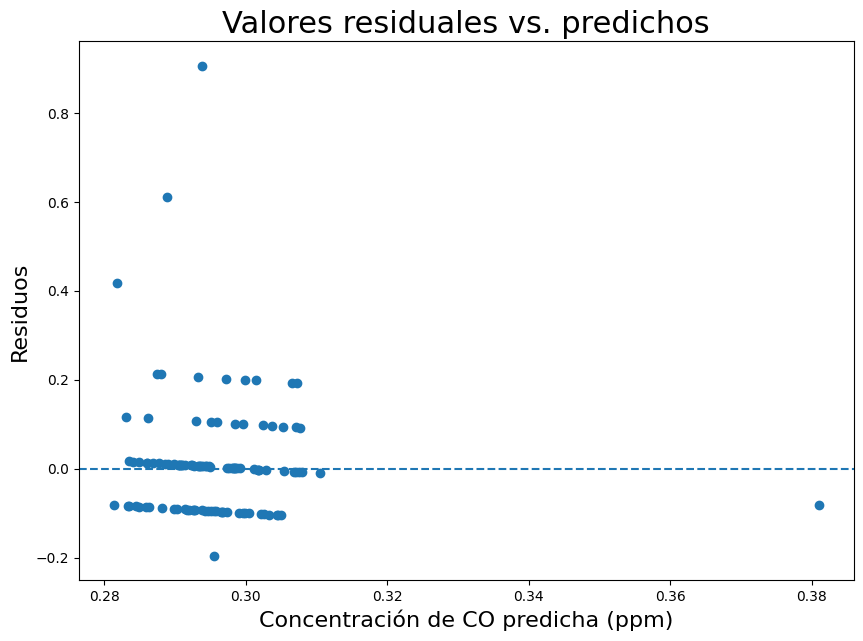

In [45]:
# Diagrama de dispersión (Homoscedasticidad)

plt.figure(figsize=(10,7))
plt.title("Valores residuales vs. predichos", fontsize=22)
plt.xlabel("Concentración de CO predicha (ppm)", fontsize=16)
plt.ylabel("Residuos", fontsize=16)
plt.scatter(x=predictions, y=residuos)
plt.axhline(0, linestyle="--")
plt.show()

# Una dispersión aproximadamente constante alrededor de cero es compatible
# con el supuesto de homoscedasticidad.

**10.1 MÉTRICAS DEL MODELO DE REGRESIÓN LINEAL**

In [46]:
from sklearn import metrics

mae = metrics.mean_absolute_error(y_test, predictions)
mse = metrics.mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, predictions)

print("MAE :", round(mae, 4))
print("MSE :", round(mse, 4))
print("RMSE:", round(rmse, 4))
print("R²  :", round(r2, 4))

# MAE  -> error absoluto medio
# MSE  -> error cuadrático medio
# RMSE -> raíz del error cuadrático medio
# R²   -> proporción de variabilidad explicada por el modelo

MAE : 0.0799
MSE : 0.0199
RMSE: 0.1411
R²  : -0.0133


**11. ÁRBOL DE DECISIÓN PARA REGRESIÓN**

En esta sección se mantiene la práctica complementaria del taller original utilizando un **conjunto de datos sintético diferente** al utilizado en la regresión lineal. Por ello, sus resultados se interpretan como una práctica sobre árboles de decisión y no como una comparación directa de desempeño con el modelo de CO de Monterey.

In [47]:
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import numpy as np

# Importar el método make_regression para generar muestras de datos artificiales
from sklearn.datasets import make_regression

In [48]:
n_samples = 100        # Número de muestras
n_features = 6         # Número de características
n_informative = 3      # Características que realmente influyen en la salida

In [49]:
X_tree, y_tree, coef = make_regression(
    n_samples=n_samples,
    n_features=n_features,
    n_informative=n_informative,
    random_state=20,
    shuffle=False,
    noise=20,
    coef=True
)

print(coef)

# random_state -> semilla aleatoria para reproducibilidad
# shuffle=False -> evita mezclar las características
# noise -> incorpora ruido aleatorio
# coef=True -> devuelve los coeficientes reales

[78.58638696 97.72361019 52.30606265  0.          0.          0.        ]


**11.1. Generación y visualización de datos de prueba**

**Data frame:**

In [50]:
df1 = pd.DataFrame(
    data=X_tree,
    columns=["X" + str(i) for i in range(1, n_features + 1)]
)

df2 = pd.DataFrame(data=y_tree, columns=["y"])

df_tree = pd.concat([df1, df2], axis=1)

df_tree.head(10)

,X1,X2,X3,X4,X5,X6,y
0,0.883893,0.195865,0.357537,-2.343262,-1.084833,0.559696,109.512132
1,0.939469,-0.978481,0.503097,0.406414,0.323461,-0.493411,52.542242
2,-0.792017,-0.842368,-1.279503,0.245715,-0.044195,1.567633,-247.679018
3,1.051109,0.406368,-0.168646,-3.189703,1.120132,1.332778,98.678111
4,-0.243339,-0.130031,-0.109017,1.556186,0.128778,-2.066949,-55.286890
5,-0.885493,-1.104579,0.932866,2.059838,-0.934938,-1.612990,-94.821349
6,0.527070,-1.551101,0.329613,-1.136527,-0.338491,0.320971,-75.940071
7,-0.602308,1.544728,0.647034,0.593217,0.438024,1.357789,139.247064
8,1.204511,1.351796,0.493437,-2.704365,-0.555186,0.001509,246.470338
9,0.857094,1.481144,-0.219661,1.503398,-1.482385,-0.856164,204.709196


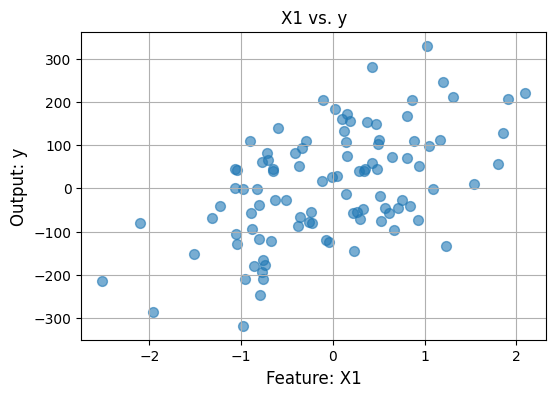

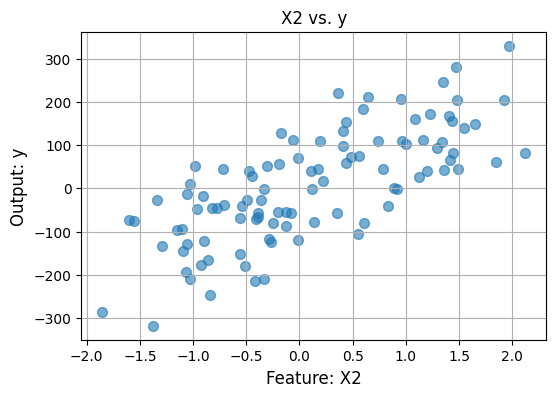

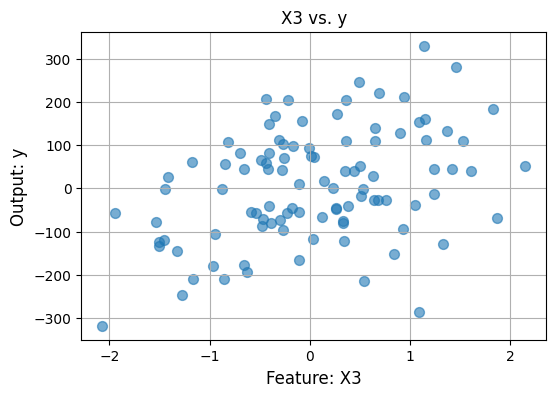

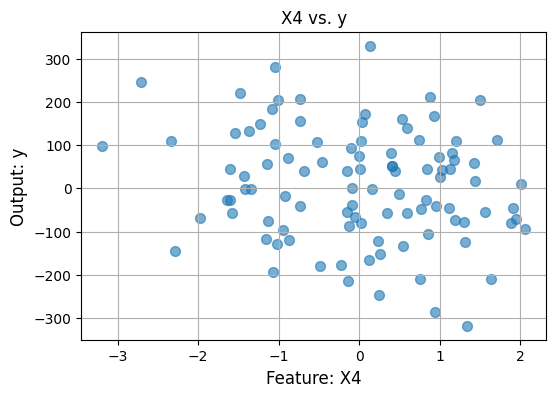

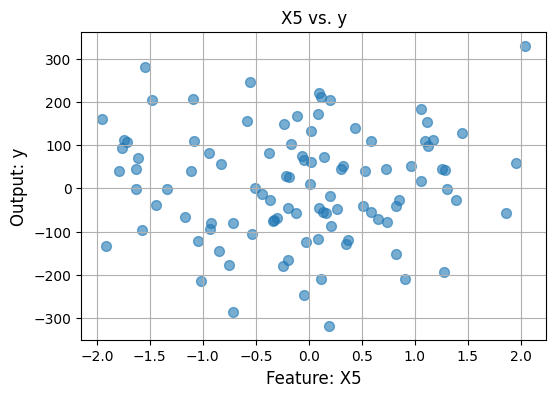

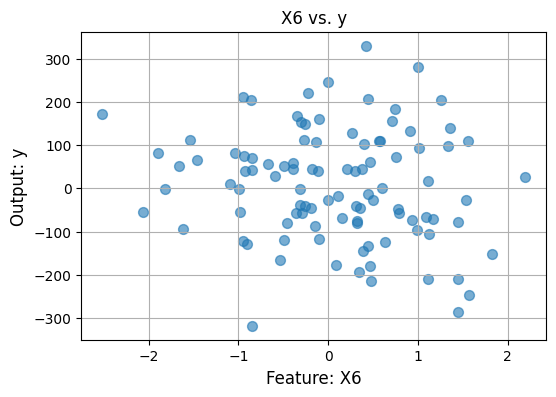

In [51]:
for col in df_tree.columns[:-1]:
    plt.figure(figsize=(6,4))
    plt.grid(True)
    plt.xlabel("Feature: " + col, fontsize=12)
    plt.ylabel("Output: y", fontsize=12)
    plt.scatter(df_tree[col], df_tree["y"], s=50, alpha=0.6)
    plt.title(col + " vs. y")
    plt.show()

In [52]:
from sklearn import tree
from sklearn.model_selection import train_test_split

X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(
    X_tree, y_tree, test_size=0.3, random_state=123
)

# Creación del modelo
tree_model = tree.DecisionTreeRegressor(
    max_depth=5,
    random_state=10
)

tree_model.fit(X_train_tree, y_train_tree)

DecisionTreeRegressor(max_depth=5, random_state=10)

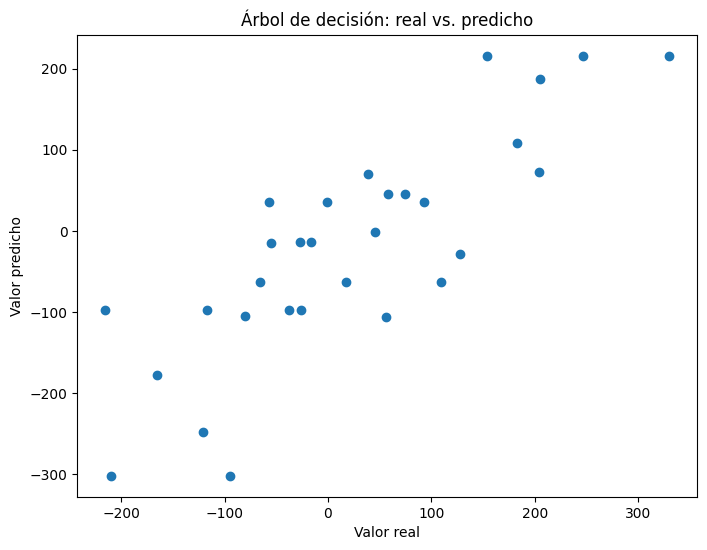

Mean square error (MSE): 7931.574768958281


In [53]:
from sklearn import metrics

# Hacemos predicciones
test_pred = tree_model.predict(X_test_tree)

plt.figure(figsize=(8,6))
plt.scatter(x=y_test_tree, y=test_pred)
plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.title("Árbol de decisión: real vs. predicho")
plt.show()

print("Mean square error (MSE):", metrics.mean_squared_error(y_test_tree, test_pred))

Importancia relativa de las características: [0.26900246 0.53730467 0.11075698 0.03758107 0.01219288 0.03316193]


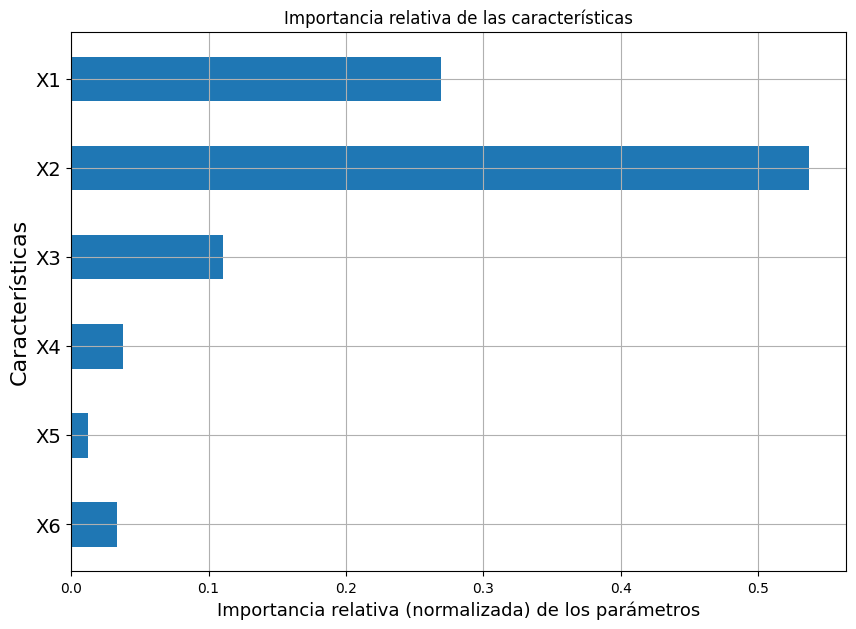

In [54]:
print(
    "Importancia relativa de las características:",
    tree_model.feature_importances_
)

plt.figure(figsize=(10, 7))
plt.grid(True)
plt.yticks(
    range(n_features, 0, -1),
    df_tree.columns[:-1],
    fontsize=14
)
plt.xlabel(
    "Importancia relativa (normalizada) de los parámetros",
    fontsize=13
)
plt.ylabel("Características", fontsize=16)
plt.barh(
    range(n_features, 0, -1),
    width=tree_model.feature_importances_,
    height=0.5
)
plt.title("Importancia relativa de las características")
plt.show()

**12. MÉTODO DE MÍNIMOS CUADRADOS**

In [55]:
import statsmodels.api as sm

# Se utiliza el mismo conjunto de variables de la regresión lineal
# para obtener el resumen estadístico mediante OLS.

In [56]:
Xs = sm.add_constant(X_train)
stat_model = sm.OLS(y_train, Xs)
stat_result = stat_model.fit()

print(stat_result.summary())

                                    OLS Regression Results                                   
Dep. Variable:     Daily Max 8-hour CO Concentration   R-squared:                       0.008
Model:                                           OLS   Adj. R-squared:                 -0.008
Method:                                Least Squares   F-statistic:                    0.5119
Date:                               Fri, 18 Sep 2026   Prob (F-statistic):              0.727
Time:                                       03:47:00   Log-Likelihood:                 128.42
No. Observations:                                255   AIC:                            -246.8
Df Residuals:                                    250   BIC:                            -229.1
Df Model:                                          4                                         
Covariance Type:                           nonrobust                                         
                       coef    std err          t      P>|t|

**13. CONCLUSIONES:**

Al ejecutar el notebook se deberán interpretar los resultados obtenidos para la base de datos de **CO de Monterey County durante 2022**. La variable objetivo utilizada es la **concentración máxima diaria de CO en 8 horas**.

- Se revisó la estructura, dimensiones y estadísticas descriptivas de la base de datos.
- Se analizó la distribución de la concentración de CO mediante un histograma y una curva de densidad.
- Se construyó una matriz de correlación para las variables numéricas.
- Para la regresión lineal se utilizaron variables temporales y de completitud de las observaciones.
- **Daily AQI Value** no se utilizó como predictor para evitar fuga de información, debido a su relación directa con la medición de calidad del aire.
- Se entrenó un modelo de regresión lineal y se evaluó mediante MAE, MSE, RMSE y R².
- Se analizaron los residuos mediante un histograma y un gráfico de residuos frente a valores predichos.
- Se desarrolló adicionalmente un árbol de decisión sobre datos sintéticos, manteniendo la práctica complementaria del taller original.
- Finalmente, se aplicó el método de mínimos cuadrados mediante **OLS** para obtener el resumen estadístico del modelo.